# Model Development, Tuning & Comparison

## Project
AI Recruitment Guardian: An Explainable Machine Learning Framework for Fake Job Detection and Risk Assessment

### Objectives
- Train five models on the preprocessed feature matrix from `02_Data_Preprocessing.ipynb`.
- Handle class imbalance properly (fraud is a small minority class).
- Cross-validate each model, then tune hyperparameters.
- Compare all five models on Accuracy, Precision, Recall, F1, and ROC-AUC.
- Produce confusion matrices and comparison graphs (report/paper deliverables).
- Select and save the best model for the Explainable AI step.

This notebook loads the exact `X_train`/`X_test`/`y_train`/`y_test` matrices and
the fitted `TfidfVectorizer`/`OneHotEncoder` saved at the end of
`02_Data_Preprocessing.ipynb` — nothing is refit here, so the feature space
stays consistent with preprocessing.


In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              roc_curve, ConfusionMatrixDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("Libraries imported successfully! ✅")

Libraries imported successfully! ✅


## Part A: Load Preprocessed Data

Loaded directly from disk — this is exactly the matrix Vanshika's preprocessing
notebook produced. No re-cleaning, no re-vectorizing happens here.

In [3]:
with open("../data/processed/train_test_split.pkl", "rb") as f:
    split_data = pickle.load(f)

X_train = split_data["X_train"]
X_test = split_data["X_test"]
y_train = split_data["y_train"]
y_test = split_data["y_test"]
numeric_cols = split_data["numeric_cols"]
categorical_cols = split_data["categorical_cols"]

with open("../data/processed/tfidf_vectorizer.pkl", "rb") as f:
    tfidf = pickle.load(f)
with open("../data/processed/onehot_encoder.pkl", "rb") as f:
    ohe = pickle.load(f)

print("X_train:", X_train.shape, " X_test:", X_test.shape)
print("Train fraud rate: %.2f%%" % (y_train.mean() * 100))
print("Test fraud rate:  %.2f%%" % (y_test.mean() * 100))

X_train: (14304, 3217)  X_test: (3576, 3217)
Train fraud rate: 4.84%
Test fraud rate:  4.84%


## Part B: Reconstruct Feature Names

The combined matrix has three blocks (TF-IDF text + one-hot categories +
numeric/flags). Reconstructing readable names for every column now means the
Random Forest / XGBoost feature importances and the SHAP explanations in the
next notebook can show **actual words and features**, not just column index
numbers like `"col_2481"`.

In [4]:
text_feature_names = tfidf.get_feature_names_out().tolist()
cat_feature_names = ohe.get_feature_names_out(categorical_cols).tolist()
all_feature_names = text_feature_names + cat_feature_names + numeric_cols

print("Text features:", len(text_feature_names))
print("Categorical features:", len(cat_feature_names))
print("Numeric/flag features:", len(numeric_cols))
print("Total:", len(all_feature_names), " | Matrix columns:", X_train.shape[1])
assert len(all_feature_names) == X_train.shape[1], "Feature name count mismatch!" 

Text features: 3000
Categorical features: 198
Numeric/flag features: 19
Total: 3217  | Matrix columns: 3217


## Part C: Why Class Imbalance Needs Explicit Handling

Fraudulent postings are a small minority of the dataset (roughly 5% in the full
EMSCAD data). Left alone, most models will learn "always predict real" as a
shortcut, since it already gets ~95% accuracy while being useless.

Two different tools are used depending on what each model supports:

- **`class_weight="balanced"`** (Logistic Regression, SVM, Random Forest) —
  automatically increases the penalty for misclassifying the minority (fraud)
  class during training, proportional to how rare it is.
- **`scale_pos_weight`** (XGBoost's equivalent mechanism) — same idea,
  computed manually as `(count of real) / (count of fraud)` in the training set.
- **Naive Bayes has no such parameter** — it's included as-is, which is itself
  part of the comparison story: does a model without imbalance handling perform
  noticeably worse on recall? That's a legitimate finding to report.

In [5]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight for XGBoost:", round(scale_pos_weight, 2))

scale_pos_weight for XGBoost: 19.64


## Part D: Baseline Models + 3-Fold Cross-Validation

Before any tuning, every model is evaluated with **stratified 3-fold
cross-validation** on the training set, scored by ROC-AUC (the right metric
for an imbalanced problem — unlike accuracy, it isn't fooled by a model that
just predicts the majority class).

A quick note on **SVM**: `LinearSVC` is used because it scales far better than
kernel SVM on a ~180+ dimensional sparse TF-IDF matrix, but it doesn't output
probabilities directly. Wrapping it in `CalibratedClassifierCV` adds a
probability estimate on top, which the ROC-AUC metric and the Trust Score
module (later) both need.

In [6]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=42
    ),
    "Naive Bayes": MultinomialNB(),
    "SVM": CalibratedClassifierCV(
        LinearSVC(class_weight="balanced", random_state=42, max_iter=5000), cv=3
    ),
    "Random Forest": RandomForestClassifier(
        class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, eval_metric="logloss",
        random_state=42, n_jobs=-1
    )
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
baseline_cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    baseline_cv_scores[name] = scores
    print(f"{name:22s} CV ROC-AUC: {scores.mean():.4f}  (+/- {scores.std():.4f})")

Logistic Regression    CV ROC-AUC: 0.9799  (+/- 0.0032)
Naive Bayes            CV ROC-AUC: 0.8255  (+/- 0.0238)
SVM                    CV ROC-AUC: 0.9825  (+/- 0.0025)
Random Forest          CV ROC-AUC: 0.9845  (+/- 0.0028)
XGBoost                CV ROC-AUC: 0.9806  (+/- 0.0031)


## Part E: Hyperparameter Tuning

`RandomizedSearchCV` is used instead of a full `GridSearchCV` — it samples a
fixed number of random parameter combinations instead of trying every single
one, which is far more practical to run on a laptop while still finding
near-optimal settings. Each model gets a small, sensible search space; scoring
is ROC-AUC and CV is 3-fold, matching Part D so results are comparable.

This step can take a few minutes to run, especially for Random Forest and
XGBoost — that's expected.

In [7]:
param_grids = {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs"]
    },
    "Naive Bayes": {
        "alpha": [0.01, 0.1, 0.5, 1.0, 2.0]
    },
    "SVM": {
        "estimator__C": [0.01, 0.1, 1, 10]
    },
    "Random Forest": {
        "n_estimators": [100, 200, 300],
        "max_depth": [None, 10, 20, 30],
        "min_samples_split": [2, 5, 10]
    },
    "XGBoost": {
        "n_estimators": [100, 200, 300],
        "max_depth": [3, 5, 7],
        "learning_rate": [0.01, 0.05, 0.1, 0.2]
    }
}

tuned_models = {}

for name, model in models.items():
    grid = param_grids[name]
    n_iter = min(10, np.prod([len(v) for v in grid.values()]))
    search = RandomizedSearchCV(
        model, grid, n_iter=n_iter, scoring="roc_auc",
        cv=cv, random_state=42, n_jobs=-1
    )
    search.fit(X_train, y_train)
    tuned_models[name] = search.best_estimator_
    print(f"{name:22s} best CV ROC-AUC: {search.best_score_:.4f}  | best params: {search.best_params_}")

Logistic Regression    best CV ROC-AUC: 0.9812  | best params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 10}
Naive Bayes            best CV ROC-AUC: 0.9512  | best params: {'alpha': 0.01}
SVM                    best CV ROC-AUC: 0.9825  | best params: {'estimator__C': 1}
Random Forest          best CV ROC-AUC: 0.9856  | best params: {'n_estimators': 300, 'min_samples_split': 10, 'max_depth': None}
XGBoost                best CV ROC-AUC: 0.9816  | best params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1}


## Part F: Evaluate Tuned Models on the Held-Out Test Set

This is the first time the test set is touched. All five tuned models are
scored on the same untouched 20% split, on all five required metrics.

**Why report all five metrics instead of just accuracy:** with ~5% fraud in the
data, a model that always predicts "real" scores ~95% accuracy while catching
zero fraud. Precision tells you how many *flagged* postings are actually fake
(false-alarm rate); Recall tells you how many *actual fakes* got caught (miss
rate); F1 balances both; ROC-AUC measures ranking quality independent of a
specific decision threshold. For a fraud detector, **Recall and F1 usually
matter more than raw Accuracy** — missing a real scam is worse than one
extra false alarm.

In [8]:
results = []
fitted_predictions = {}

for name, model in tuned_models.items():
    preds = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    fitted_predictions[name] = {"preds": preds, "proba": proba}

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1-score": f1_score(y_test, preds, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, proba)
    })

comparison_df = pd.DataFrame(results).sort_values("F1-score", ascending=False).reset_index(drop=True)
comparison_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,XGBoost,0.986857,0.920000,0.797688,0.854489,0.992992
1,SVM,0.986018,0.948905,0.751445,0.838710,0.984747
2,Random Forest,0.983221,0.924812,0.710983,0.803922,0.993600
3,Logistic Regression,0.977629,0.720379,0.878613,0.791667,0.982447
4,Naive Bayes,0.966723,0.664634,0.630058,0.646884,0.955310


## Part G: Confusion Matrices

A confusion matrix shows exactly *what kind* of mistakes each model makes —
false positives (real jobs wrongly flagged as fake) vs. false negatives (fake
jobs that slipped through as "real"). For this project, false negatives are
the costlier mistake — a missed scam can directly harm a user.

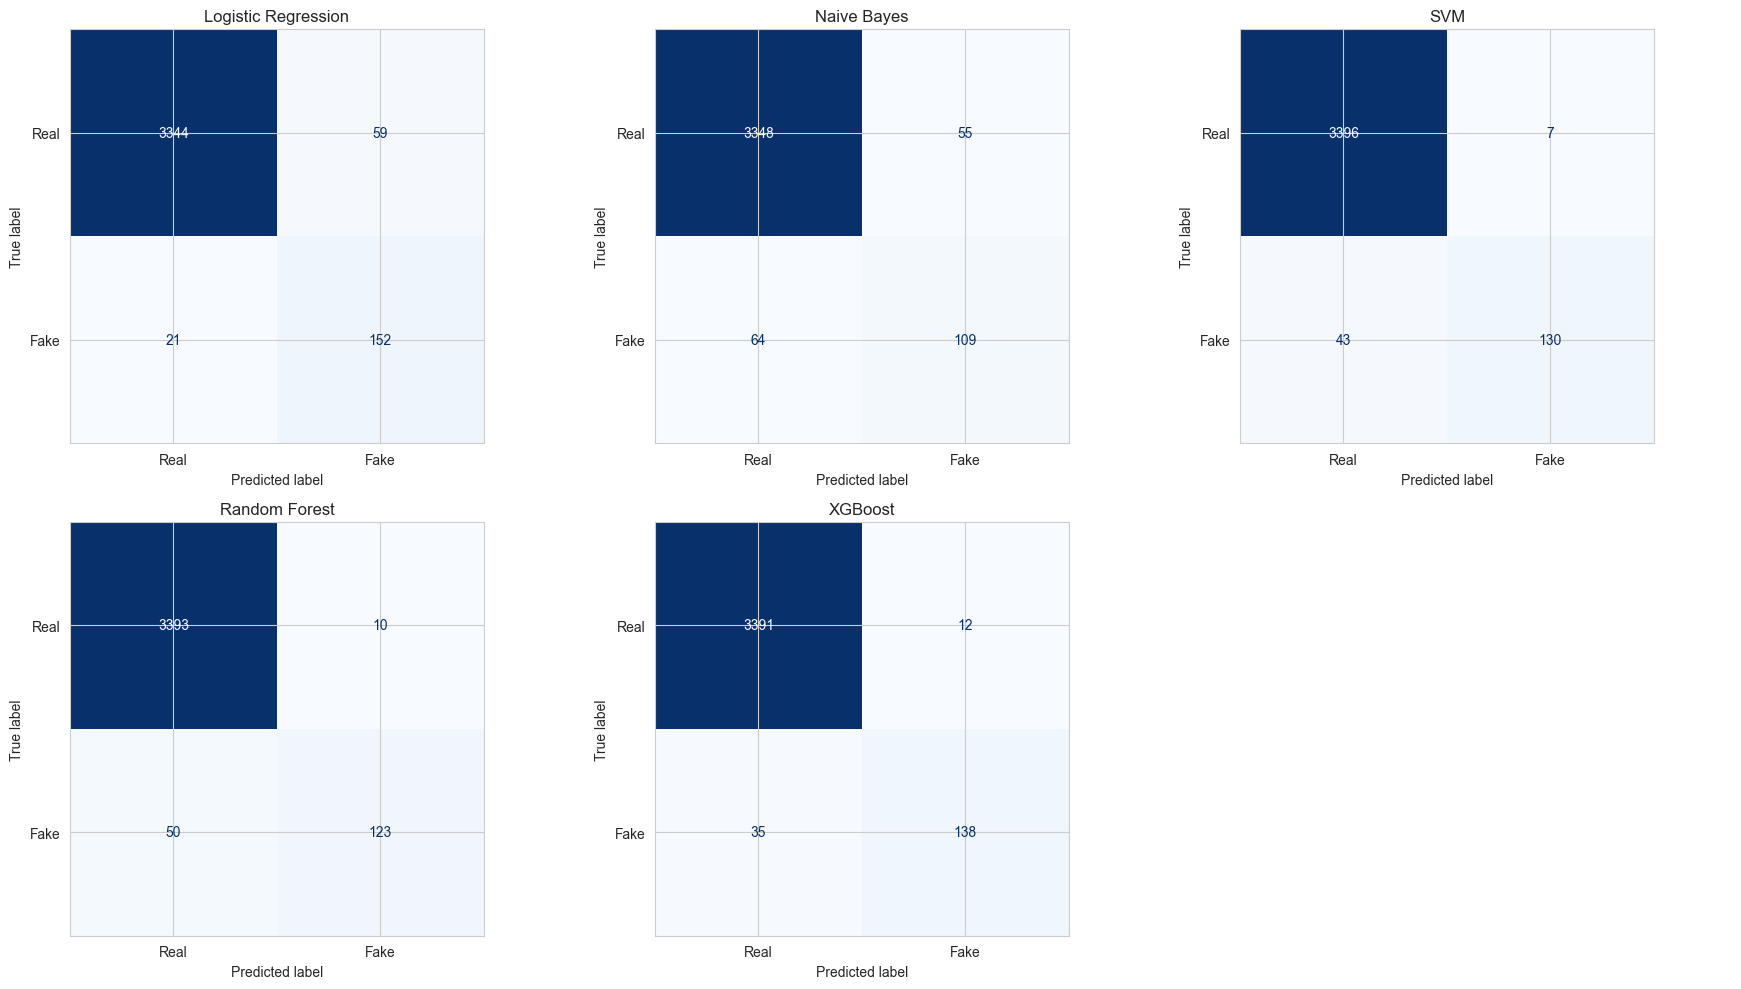

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(tuned_models.items()):
    cm = confusion_matrix(y_test, fitted_predictions[name]["preds"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Real", "Fake"])
    disp.plot(ax=axes[i], colorbar=False, cmap="Blues")
    axes[i].set_title(name)

axes[-1].axis("off")
plt.tight_layout()
plt.savefig("../reports/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

## Part H: Performance Comparison Graph

A single bar chart comparing all five models across all five metrics — this is
the figure most report/paper reviewers look at first.

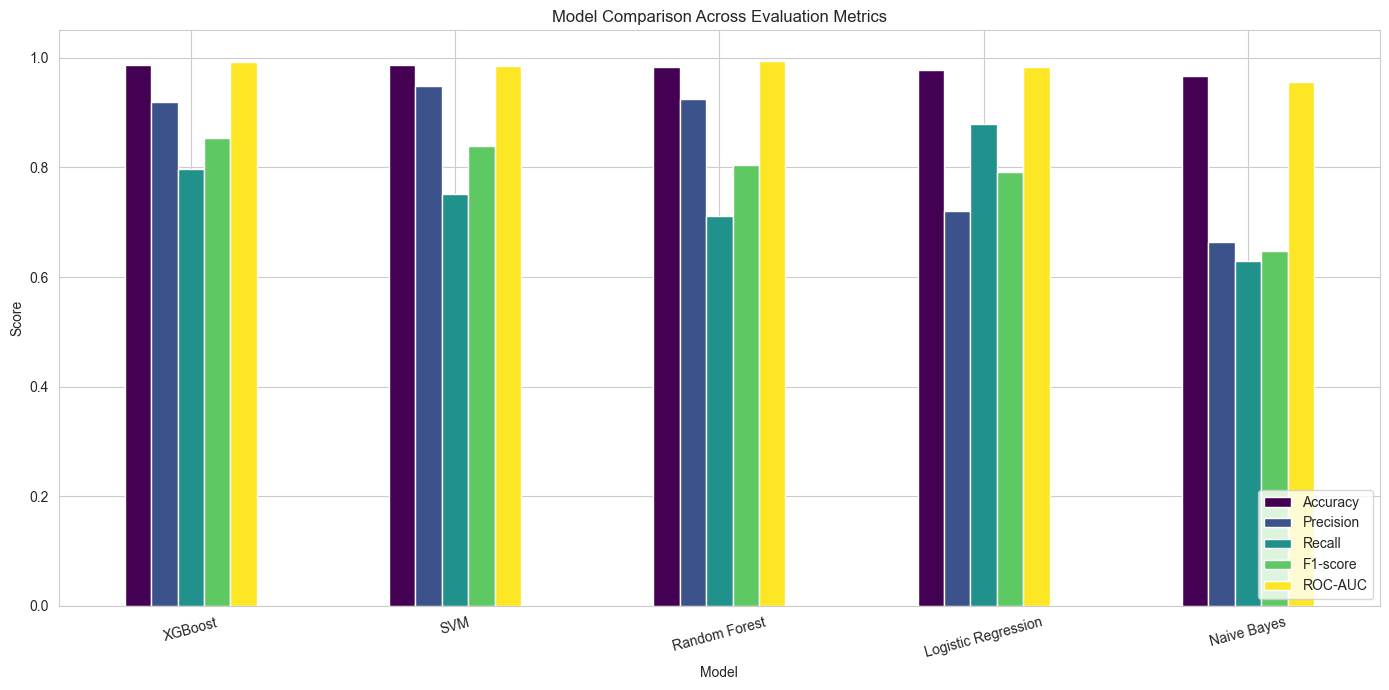

In [10]:
plot_df = comparison_df.set_index("Model")
plot_df.plot(kind="bar", figsize=(14, 7), colormap="viridis")
plt.title("Model Comparison Across Evaluation Metrics")
plt.ylabel("Score")
plt.xticks(rotation=15)
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/model_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()

## Part I: ROC Curves

All five ROC curves on one plot make it easy to see which model separates
fake from real postings best across every possible decision threshold — not
just the default 0.5 cutoff used for the confusion matrices above.

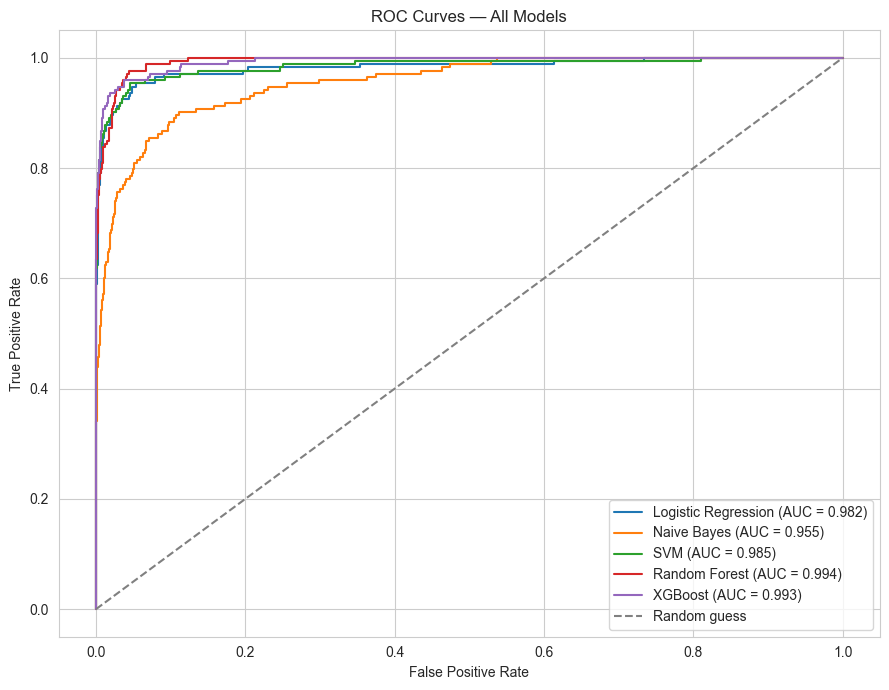

In [11]:
plt.figure(figsize=(9, 7))

for name, model in tuned_models.items():
    fpr, tpr, _ = roc_curve(y_test, fitted_predictions[name]["proba"])
    auc = roc_auc_score(y_test, fitted_predictions[name]["proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("../reports/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Part J: Select and Save the Best Model

The best model is chosen by **F1-score**, not accuracy — consistent with the
reasoning in Part F. ROC-AUC is reported alongside as a secondary check since
it's threshold-independent.

The saved model, plus the reconstructed feature names, are exactly what
`04_Explainable_AI.ipynb` (SHAP/LIME) will load next — nothing gets retrained
there.

In [12]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = tuned_models[best_model_name]

print(f"Best model selected: {best_model_name}")
print(comparison_df.iloc[0])

import os
os.makedirs("../models", exist_ok=True)

with open("../models/best_model.pkl", "wb") as f:
    pickle.dump({
        "model": best_model,
        "model_name": best_model_name,
        "feature_names": all_feature_names,
        "text_feature_count": len(text_feature_names),
        "cat_feature_count": len(cat_feature_names),
        "numeric_feature_count": len(numeric_cols)
    }, f)

with open("../models/all_tuned_models.pkl", "wb") as f:
    pickle.dump(tuned_models, f)

comparison_df.to_csv("../reports/model_comparison_table.csv", index=False)

print("\nSaved: ../models/best_model.pkl")
print("Saved: ../models/all_tuned_models.pkl")
print("Saved: ../reports/model_comparison_table.csv")

Best model selected: XGBoost
Model         XGBoost
Accuracy     0.986857
Precision        0.92
Recall       0.797688
F1-score     0.854489
ROC-AUC      0.992992
Name: 0, dtype: object

Saved: ../models/best_model.pkl
Saved: ../models/all_tuned_models.pkl
Saved: ../reports/model_comparison_table.csv


## Summary

| Step | Output |
|---|---|
| Class imbalance handling | `class_weight="balanced"` (LogReg/SVM/RF), `scale_pos_weight` (XGBoost), Naive Bayes left as baseline-without-handling |
| Cross-validation | Stratified 3-fold ROC-AUC, before and after tuning |
| Hyperparameter tuning | `RandomizedSearchCV`, 3-fold, up to 10 combinations per model |
| Evaluation | Accuracy, Precision, Recall, F1, ROC-AUC on held-out test set |
| Deliverables produced | `model_comparison_table.csv`, confusion matrix grid, comparison bar chart, ROC curve overlay — all saved to `../reports/` |
| Model selection | Best model chosen by F1-score (not accuracy, due to class imbalance) |
| Artifacts saved | `../models/best_model.pkl` (with feature names), `../models/all_tuned_models.pkl` |

**Next step:** `04_Explainable_AI.ipynb` — load `best_model.pkl`, apply SHAP to
explain individual predictions, build the Job Trust Score from SHAP values +
suspicious phrase flags, and generate the risk indicator list for the
dashboard.